In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr

In [2]:
df = pd.read_csv('../../data/final_dataset.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   post_id            332 non-null    str    
 1   post_title         332 non-null    str    
 2   time_posted        332 non-null    int64  
 3   24hr_score         332 non-null    float64
 4   selftext           211 non-null    str    
 5   has_selftext       332 non-null    bool   
 6   text_length        332 non-null    int64  
 7   hour               332 non-null    int64  
 8   day_of_week        332 non-null    int64  
 9   is_weekend         332 non-null    int64  
 10  hour_sin           332 non-null    float64
 11  hour_cos           332 non-null    float64
 12  dow_sin            332 non-null    float64
 13  dow_cos            332 non-null    float64
 14  title_len          332 non-null    int64  
 15  title_word_count   332 non-null    int64  
 16  title_punct_count  332 non-null    in

In [11]:
def is_black_friday(dt):
    year = dt.year
    start = pd.Timestamp(year=year, month = 11, day = 24, tz='UTC')
    end = pd.Timestamp(year= year, month = 12, day = 2, tz='UTC')
    
    return int(start <= dt <= end)

In [12]:
df['time_posted'] = pd.to_datetime(df['time_posted'], unit='s', utc=True)

In [13]:
df['is_black_friday'] = df['time_posted'].apply(is_black_friday)

In [14]:
df['is_black_friday'].sum()

np.int64(81)

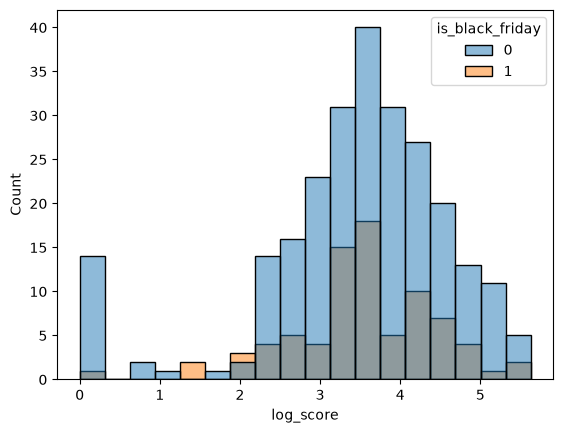

In [33]:
sns.histplot(df, x = 'log_score', hue='is_black_friday');

In [34]:
df.groupby('is_black_friday')['log_score'].describe()


,count,mean,std,min,25%,50%,75%,max
is_black_friday,,,,,,,,
0,251.0,3.461231,1.181145,0.0,2.995732,3.583519,4.182021,5.627621
1,81.0,3.539032,0.933152,0.0,3.135494,3.496508,4.234107,5.552960


In [36]:
bf = df[df['is_black_friday']==1]['log_score']
non_bf = df[df['is_black_friday']==0]['log_score']
stats.levene(bf, non_bf)

LeveneResult(statistic=np.float64(2.294575889216593), pvalue=np.float64(0.13078387171018804))

In [37]:
stats.mannwhitneyu(bf, non_bf)

MannwhitneyuResult(statistic=np.float64(10085.0), pvalue=np.float64(0.9151674408933589))

Hypothesized that Black Friday/Cyber Monday period posts (n=81) might show different engagement patterns than other posts (n=251) — either in central tendency or variance — motivated by a ~23% volume spike in a single week and a marginal visual difference in the score distribution. Tested via Mann-Whitney U (p=0.915) for location and Levene's test (p=0.131) for variance; neither was significant. Did not include a seasonal flag as a result.

In [38]:
df = df.drop(columns='is_black_friday')

In [39]:
TEST_SIZE = 50 # ~15% of the dataset

train_df = df.iloc[:-TEST_SIZE].copy()
test_df = df.iloc[-TEST_SIZE:].copy()

print(len(train_df), len(test_df))

282 50


chose fold boundaries to balance training-set adequacy against validation-block stability, anchored to the observed weekly posting cadence
 -  the sparsity in Aug/Sept
 -  wanting balanced-ish validation blocks above a noise floor
 -  using the natural weekly volume pattern

In [40]:
def expanding_folds(n):
    splits = [
        (0, 110, 110, 165),
        (0, 165, 165, 220),
        (0, 220, 220, n)
    ]
    
    folds = []
    
    for train_start, train_end, val_start, val_end in splits:
        train_idx = np.arange(train_start, min(train_end, n))
        val_idx = np.arange(val_start, min(val_end, n))
        
        folds.append((train_idx, val_idx))
    
    return folds

In [41]:
folds = expanding_folds(len(train_df))

for i, (train_idx, val_idx) in enumerate(folds):
    print(f"\nFold {i+1}")
    print("Train size:", len(train_idx))
    print("Val size:", len(val_idx))

    print("Train end:", train_df.iloc[train_idx[-1]]['time_posted'])
    print("Val start:", train_df.iloc[val_idx[0]]['time_posted'])


Fold 1
Train size: 110
Val size: 55
Train end: 2025-10-22 15:09:51+00:00
Val start: 2025-10-23 02:11:06+00:00

Fold 2
Train size: 165
Val size: 55
Train end: 2025-11-10 20:14:18+00:00
Val start: 2025-11-11 01:28:39+00:00

Fold 3
Train size: 220
Val size: 62
Train end: 2025-11-21 23:22:21+00:00
Val start: 2025-11-22 00:09:55+00:00


1. median baseline

In [42]:
y = train_df['log_score']

In [49]:
baseline_results = []

for i, (train_idx, val_idx) in enumerate(folds):

    
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    median_prediction = y_train.median()

    preds_log = np.full(len(y_val), median_prediction)

    mae = mean_absolute_error(y_val, preds_log)
    
    preds_raw = np.expm1(preds_log)
    y_val_raw = np.expm1(y_val)
    
    raw_mae = mean_absolute_error(y_val_raw, preds_raw)
    
    spearman = spearmanr(y_val, preds_log).correlation

    baseline_results.append({
        "fold": i + 1,
        "train_size": len(train_idx),
        "val_size": len(val_idx),
        "train_median": median_prediction,
        "MAE": mae,
        "raw_MAE": raw_mae,
        "Spearman": spearman
    })


baseline_df = pd.DataFrame(baseline_results)

baseline_df

C:\Users\Jaden\AppData\Local\Temp\ipykernel_19076\2942106616.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman = spearmanr(y_val, preds_log).correlation
C:\Users\Jaden\AppData\Local\Temp\ipykernel_19076\2942106616.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman = spearmanr(y_val, preds_log).correlation
C:\Users\Jaden\AppData\Local\Temp\ipykernel_19076\2942106616.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman = spearmanr(y_val, preds_log).correlation


,fold,train_size,val_size,train_median,MAE,raw_MAE,Spearman
0,1,110,55,3.760930,0.852984,29.123678,NaN
1,2,165,55,3.663562,0.651213,24.854545,NaN
2,3,220,62,3.624252,0.712219,29.418602,NaN


~24.9 to 29.4 points off, against a raw 24hr_score mean of ~50 (median 35) — so the dumb baseline is off by roughly 50-85% of the median score

Spearman is undefined for constant baseline since predictions have no variance.